In [31]:
import pandas as pd

# Convertendo o link de edição para um link de exportação CSV
sheet_id = '1w7vBNjmeu3v327z5Kp664H6Tuc4J2fkS_aZAN6vmccw'
csv_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

try:
    df = pd.read_csv(csv_url)
    print("Dados carregados com sucesso via CSV (sem necessidade de login)!")
    display(df.head())
except Exception as e:
    print(f"Erro ao carregar: {e}. Certifique-se de que a planilha está configurada como 'Qualquer pessoa com o link' pode ler.")

Dados carregados com sucesso via CSV (sem necessidade de login)!


,Carimbo de data/hora,Você ficou gripado no ano passado ?,Você tomou vacina da gripe no ano passado?,"Você frequentou no ano passado, semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)",Você viajou no ano passado mais de 100 km de distância?,"Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?",Quantas horas você dormiu em média por noite no ano passado?,Você praticou atividade física no ano passado?,Você se alimentou de forma balanceada no ano passado?,"Em média, quantas vezes você lavou as mãos por dia no ano passado?","Na sua percepção, o seu nível de estresse no ano passado foi:"
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

if 'df' in locals():
    # 1. Limpeza rigorosa
    df_opt = df.dropna().copy()

    # 2. Codificação
    le = LabelEncoder()
    for col in df_opt.columns:
        if df_opt[col].dtype == 'object':
            df_opt[col] = le.fit_transform(df_opt[col].astype(str))

    # 3. Definição de X e y
    X = df_opt.iloc[:, :-1]
    y = df_opt.iloc[:, -1]

    # 4. Normalização (ajuda o GaussianNB com distribuições variadas)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5. Balanceamento de Classes (SMOTE)
    # Como há poucas amostras de algumas classes, o SMOTE cria exemplos sintéticos
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_res, y_res = smote.fit_resample(X_scaled, y)

    # 6. Divisão Treino/Teste
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

    # 7. Treinamento
    model = GaussianNB()
    model.fit(X_train, y_train)

    # 8. Avaliação
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f'Nova Acurácia com Balanceamento e Escalonamento: {acc:.2%}')
    print('\nRelatório de Classificação:')
    print(classification_report(y_test, y_pred))
else:
    print('Erro: Carregue os dados primeiro.')

Nova Acurácia com Balanceamento e Escalonamento: 61.43%

Relatório de Classificação:
              precision    recall  f1-score   support

         1.0       0.92      1.00      0.96        12
         2.0       0.58      0.85      0.69        13
         3.0       0.57      0.40      0.47        20
         4.0       0.44      0.36      0.40        11
         5.0       0.53      0.57      0.55        14

    accuracy                           0.61        70
   macro avg       0.61      0.64      0.61        70
weighted avg       0.61      0.61      0.60        70



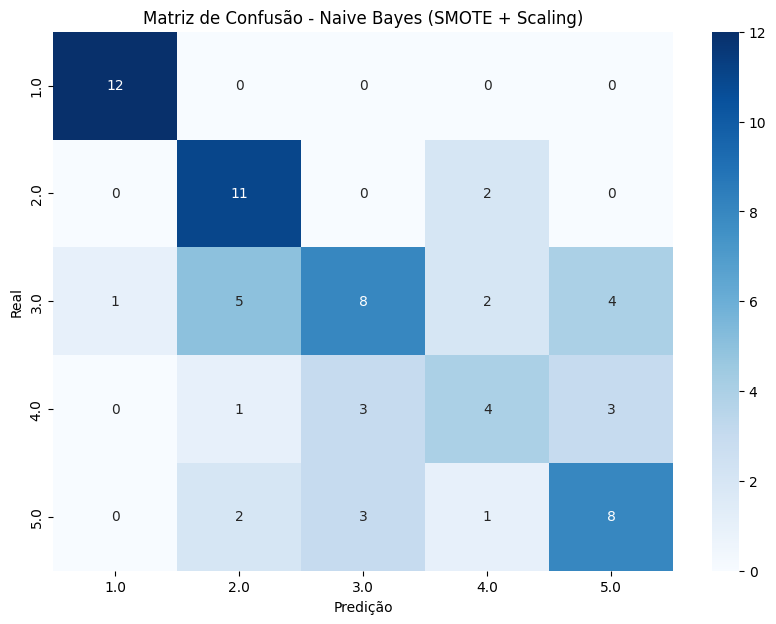

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gerando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_res),
            yticklabels=np.unique(y_res))
plt.xlabel('Predição')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Naive Bayes (SMOTE + Scaling)')
plt.show()